# Setup

## Imports

In [1]:
import matplotlib
import scanpy as sc
import anndata

import scEcho

In [2]:
%matplotlib inline
matplotlib.rcParams["figure.figsize"] = [8, 8]
matplotlib.rcParams["figure.dpi"] = 125
matplotlib.rcParams["image.cmap"] = "Spectral_r"

# no bounding boxes or axis:
matplotlib.rcParams["axes.spines.bottom"] = "on"
matplotlib.rcParams["axes.spines.top"] = "off"
matplotlib.rcParams["axes.spines.left"] = "on"
matplotlib.rcParams["axes.spines.right"] = "off"

## Data

In [3]:
retina_ad = anndata.read_h5ad("D59_retina.h5ad")
retina_ad

AnnData object with n_obs × n_vars = 5412 × 23519
    obs: 'nCount.RNA', 'nFeature.RNA', 'S.Score', 'G2M.Score', 'Phase', 'RGC1_branch_RNA', 'RGC2_branch_RNA', 'RGC3_branch_RNA', 'HRZ_branch_RNA', 'CON_branch_RNA', 'RGC_branch_RNA', 'RNA_pseudotime', 'RGC1_branch_ATAC', 'RGC2_branch_ATAC', 'RGC3_branch_ATAC', 'HRZ_branch_ATAC', 'CON_branch_ATAC', 'RGC_branch_ATAC', 'ATAC_pseudotime', 'SEACell', 'OTX2_DHS4', 'combo_type'
    var: 'gene_ids', 'feature_types', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'gene_name', 'n_cells_noBIP'
    uns: 'BIP.type_colors', 'CON_branch_ATAC_set_colors', 'DM_EigenValues', 'EigenValues', 'HRZ_branch_ATAC_set_colors', 'Phase_colors', 'RGC_branch_ATAC_set_colors', 'celltype_ATAC_colors', 'combo_type_colors', 'direction_colors', 'hvg', 'leiden', 'lin_colors', 'neighbors', 'palantir_waypoints', 'pca', 'pst_grp_colors', 'umap'
    obsm: 'ATAC_ArchR_iLSI', 'ATAC_umap', 'ATAC_umap_rotated', 'DM_EigenVectors_ATAC', 'DM_EigenVectors_R

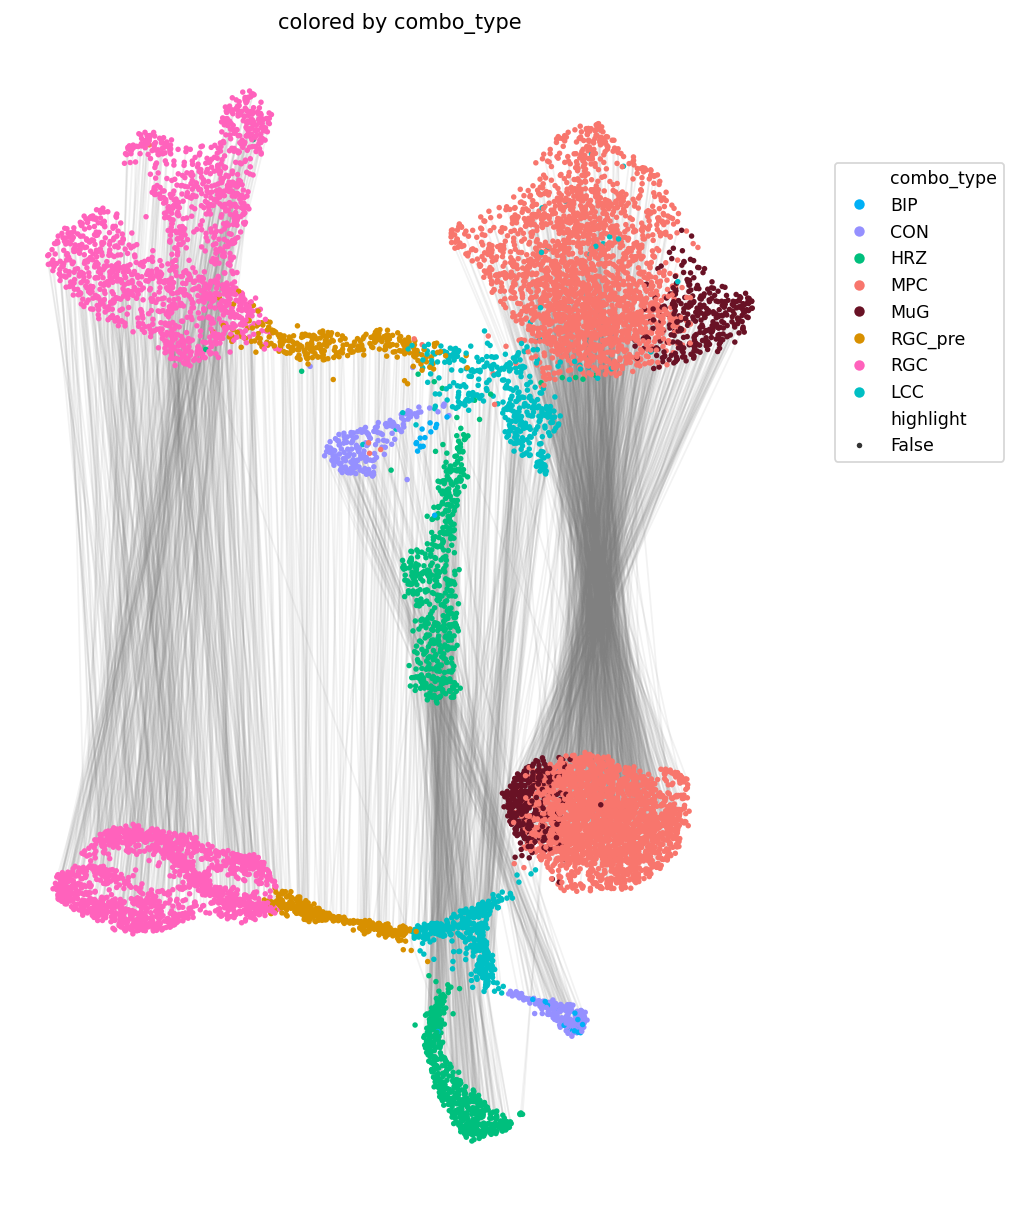

In [4]:
l_plot = scEcho.plotting.linked_plot(retina_ad,
                                  embedding1 = "RNA_UMAP_2d",
                                  embedding2 = "ATAC_umap_rotated", 
                                  downsample_lines_frac=.3, 
                                  line_alpha=.1, 
                                  color_by="combo_type")

# Echo states

In [5]:
scEcho.Echo_states.dn_comp_obsm(retina_ad,
    obsm_key1='DM_EigenVectors_RNA',
    obsm_key2='DM_EigenVectors_ATAC',
                             
    pval_threshold=0.05,
    log_fold_change_threshold=.7, 
                ls_factor = 2
)

RNA fractal dimensionality:  1.8780125365979963
ATAC fractal dimensionality: 1.8569060210876294
Using dimensionality:        1.8780125365979963


  0%|          | 0/2 [00:00<?, ?it/s]

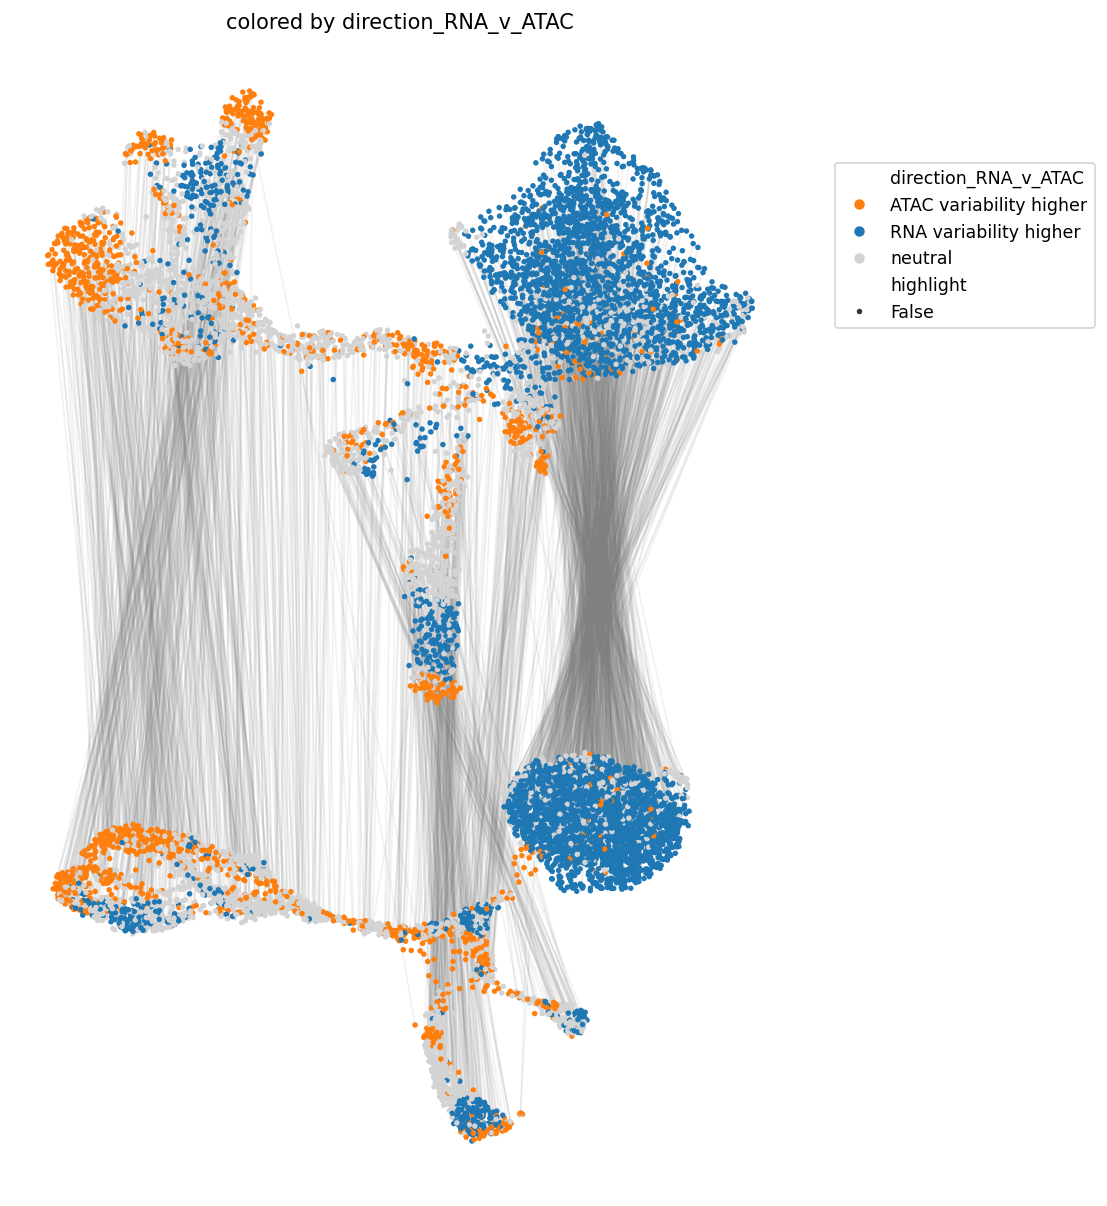

In [6]:
l_plot = scEcho.plotting.linked_plot(retina_ad,
                                  embedding1 = "RNA_UMAP_2d",
                                  embedding2 = "ATAC_umap_rotated", 
                                  downsample_lines_frac=.3, 
                                  line_alpha=.1, 
                                  color_by="direction_RNA_v_ATAC")

In [2]:
pbar = scEcho.plotting.plot_direction_fractions(retina_rna, obs_col = "combo_type", figsize=(8, 4))

NameError: name 'scEcho' is not defined

# Echo Features

In [ ]:
scEcho.Echo_features.run_echo_features(
    retina_ad,
    obs_col="combo_type",
    layers=["RNA_lognorm_counts"],
    sigma=0.1,
    ls=10**(-0.5),
)

[run_desynch_full] Processing layer: 'RNA_lognorm_counts'
  - embeddings_predict_layer


  0%|          | 0/2 [00:00<?, ?it/s]